In [ ]:
pip install pandas scikit-learn imbalanced-learn matplotlib seaborn shap


Data types of columns:
FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                    

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


After SMOTE: Class distribution in y_train_resampled: 0    107815
1    107815
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by Random Forest: Index(['FILENAME', 'URL', 'Domain', 'URLSimilarityIndex', 'LineOfCode',
       'HasSocialNet', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfExternalRef'],
      dtype='object')
Running time: 44.28568 seconds
Random Forest Accuracy (Selected Features): 1.0
Random Forest ROC-AUC (Selected Features): 1.0
Random Forest Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



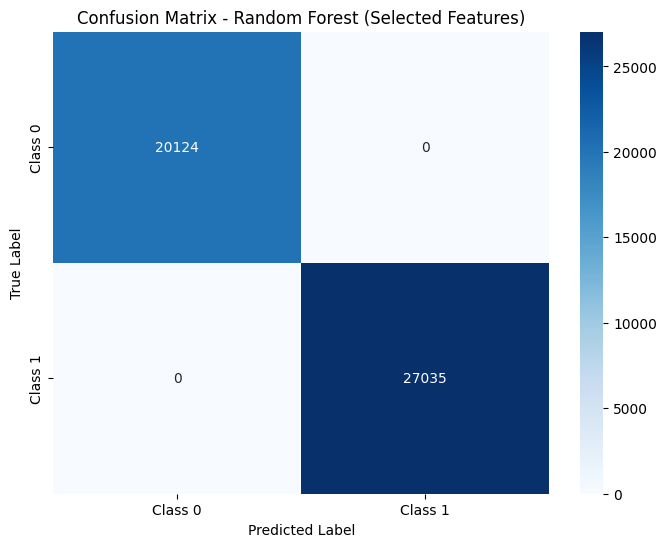

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os  
os.environ["LOKY_MAX_CPU_COUNT"] = "YOUR_LOGICAL_CORES_COUNT"

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_235795_54.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using Random Forest
# Train an initial Random Forest model to get feature importances
rf_initial_model = RandomForestClassifier(random_state=42)
rf_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on Random Forest feature importances
feature_selector = SelectFromModel(rf_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by Random Forest: {selected_features}")

# Step 6: Train final Random Forest model with selected features
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = rf_model.predict(X_test_selected)
y_proba = rf_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")

print(f"Random Forest Accuracy (Selected Features): {rf_accuracy}")
print(f"Random Forest ROC-AUC (Selected Features): {rf_roc_auc}")
print("Random Forest Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - Random Forest (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for Random Forest
# Create a SHAP explainer for Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)[1]  # Use shap_values[1] for class 1 in binary classification

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for Random Forest (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (Random Forest)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value[1], shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (Random Forest)")
plt.show()


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os  
os.environ["LOKY_MAX_CPU_COUNT"] = "YOUR_LOGICAL_CORES_COUNT"

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_235795_54.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using Random Forest
# Train an initial Random Forest model to get feature importances
rf_initial_model = RandomForestClassifier(random_state=42)
rf_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on Random Forest feature importances
feature_selector = SelectFromModel(rf_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by Random Forest: {selected_features}")

# Step 6: Train final Random Forest model with selected features
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = rf_model.predict(X_test_selected)
y_proba = rf_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")

print(f"Random Forest Accuracy (Selected Features): {rf_accuracy}")
print(f"Random Forest ROC-AUC (Selected Features): {rf_roc_auc}")
print("Random Forest Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - Random Forest (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for Random Forest
# Create a SHAP explainer for Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Check the shapes of SHAP values and test data to debug potential mismatches
print(f"Shape of X_test_selected: {X_test_selected.shape}")
print(f"Shape of shap_values: {np.array(shap_values).shape}")

# For binary classification, shap_values is a list of two arrays (one for each class)
if isinstance(shap_values, list) and len(shap_values) > 1:
    # Use SHAP values for class 1
    shap_values = shap_values[1]
    print(f"Using SHAP values for class 1, shape: {shap_values.shape}")

# Ensure the number of features in SHAP values matches the test data
assert shap_values.shape[1] == X_test_selected.shape[1], f"Shape mismatch: SHAP values shape {shap_values.shape} and X_test_selected shape {X_test_selected.shape}"

# Plot SHAP summary plot using the matched SHAP values and features
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for Random Forest (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (Random Forest)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value[1], shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (Random Forest)")
plt.show()


Data types of columns:
FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                    

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


After SMOTE: Class distribution in y_train_resampled: 0    107815
1    107815
dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by Random Forest: Index(['FILENAME', 'URL', 'Domain', 'URLSimilarityIndex', 'LineOfCode',
       'HasSocialNet', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfExternalRef'],
      dtype='object')
Running time: 39.91052 seconds
Random Forest Accuracy (Selected Features): 1.0
Random Forest ROC-AUC (Selected Features): 1.0
Random Forest Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



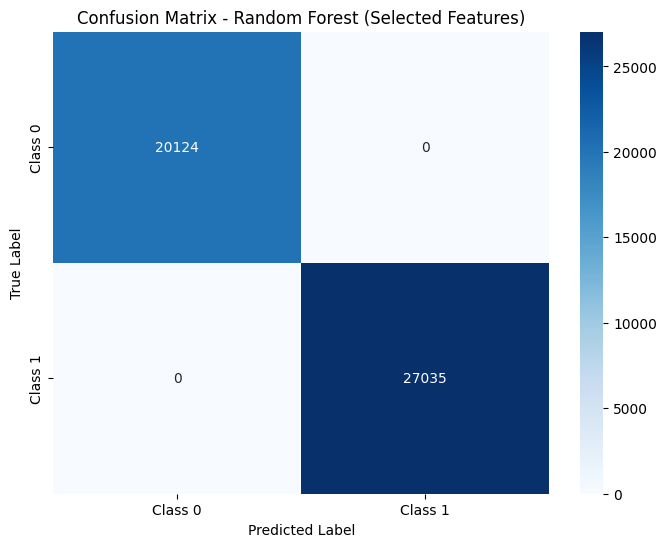

Shape of shap_values: (47159, 12, 2)
Shape of X_test_selected: (47159, 12)
Shape of shap_values after selection: (47159, 12, 2)


<Figure size 640x480 with 0 Axes>

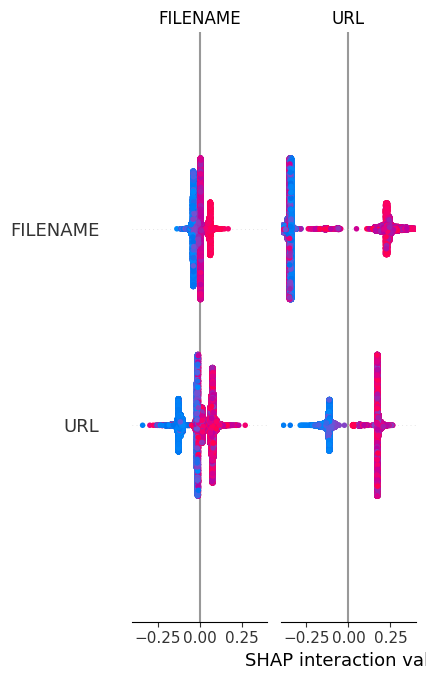

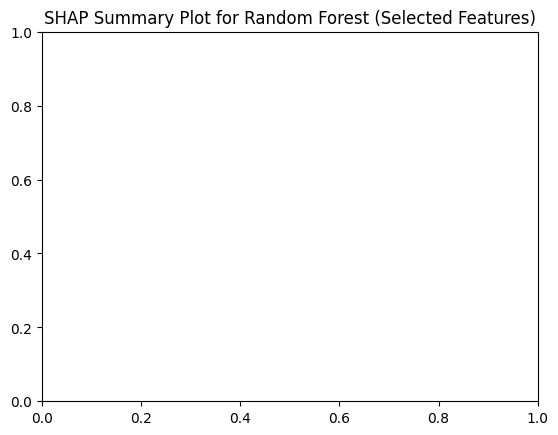

<Figure size 640x480 with 0 Axes>

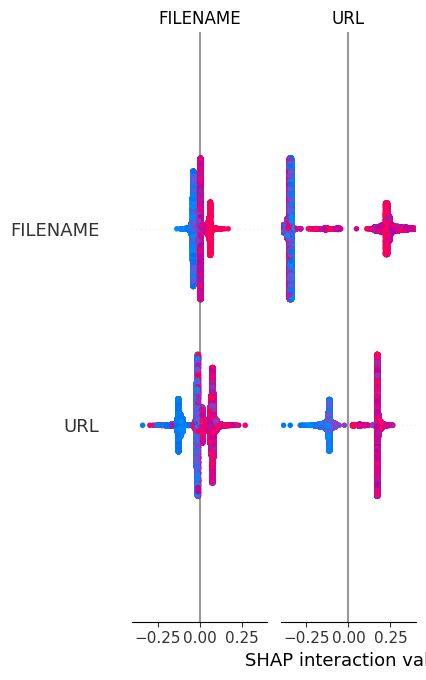

NotImplementedError: matplotlib = True is not yet supported for force plots with multiple samples!

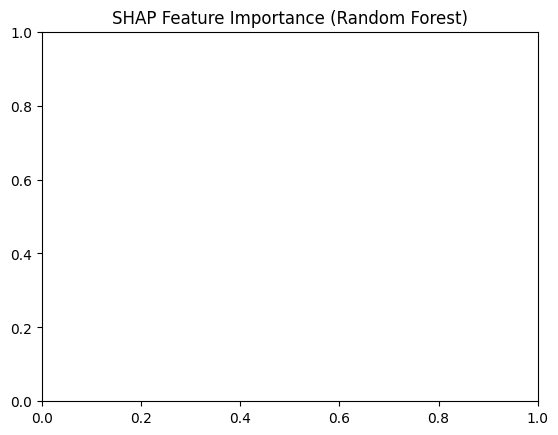

<Figure size 640x480 with 0 Axes>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os  

# Set the logical cores count for parallelism (if needed)
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

# Track start time
start_time = time.time()

# Step 1: Load dataset
df = pd.read_csv('ds_235795_54.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using Random Forest
# Train an initial Random Forest model to get feature importances
rf_initial_model = RandomForestClassifier(random_state=42)
rf_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on Random Forest feature importances
feature_selector = SelectFromModel(rf_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by Random Forest: {selected_features}")

# Step 6: Train final Random Forest model with selected features
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = rf_model.predict(X_test_selected)
y_proba = rf_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")

print(f"Random Forest Accuracy (Selected Features): {rf_accuracy}")
print(f"Random Forest ROC-AUC (Selected Features): {rf_roc_auc}")
print("Random Forest Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - Random Forest (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for Random Forest
# Create a SHAP explainer for Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Check the shapes of shap_values and X_test_selected to ensure they match
print(f"Shape of shap_values: {np.array(shap_values).shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

# For binary classification, use shap_values[1] for class 1
if isinstance(shap_values, list) and len(shap_values) > 1:
    shap_values = shap_values[1]

# Check again after selecting the correct class shap_values
print(f"Shape of shap_values after selection: {shap_values.shape}")

# Ensure that SHAP values and X_test_selected have compatible shapes
assert shap_values.shape[1] == X_test_selected.shape[1], "Shape mismatch between SHAP values and test set!"

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for Random Forest (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (Random Forest)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 1
plt.figure()
shap.force_plot(explainer.expected_value[1], shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (Random Forest)")
plt.show()


Data types of columns:
qty_dot_url             int64
qty_hyphen_url          int64
qty_underline_url       int64
qty_slash_url           int64
qty_questionmark_url    int64
                        ...  
qty_redirects           int64
url_google_index        int64
domain_google_index     int64
url_shortened           int64
phishing                int64
Length: 112, dtype: object
Before SMOTE: Class distribution in y_train: 0    62155
1    41603
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: 1    62155
0    62155
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by Random Forest: Index(['qty_dot_url', 'qty_slash_url', 'length_url', 'qty_dot_domain',
       'qty_vowels_domain', 'domain_length', 'qty_dot_directory',
       'qty_underline_directory', 'qty_slash_directory', 'qty_equal_directory',
       'qty_at_directory', 'qty_and_directory', 'qty_exclamation_directory',
       'qty_tilde_directory', 'qty_comma_directory', 'qty_asterisk_directory',
       'qty_dollar_directory', 'qty_percent_directory', 'directory_length',
       'qty_dot_file', 'qty_slash_file', 'qty_questionmark_file',
       'qty_equal_file', 'qty_at_file', 'qty_space_file', 'qty_tilde_file',
       'qty_comma_file', 'qty_plus_file', 'qty_asterisk_file', 'file_length',
       'time_response', 'asn_ip', 'time_domain_activation',
       'time_domain_expiration', 'qty_nameservers', 'qty_mx_servers',
       'ttl_hostname'],
      dtype='object')
Running time: 36.50602 seconds
Random Forest Accuracy (Selected Features): 0.9887818041634541
Random Forest ROC-AUC (Se

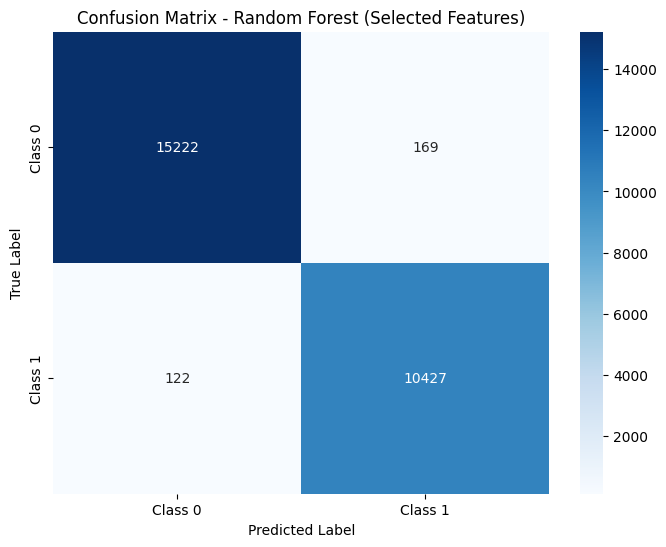

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os  

# Set the logical cores count for parallelism (if needed)
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

# Track start time
start_time = time.time()

# Step 1: Load dataset
df = pd.read_csv('ds_129K112.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using Random Forest
# Train an initial Random Forest model to get feature importances
rf_initial_model = RandomForestClassifier(random_state=42)
rf_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on Random Forest feature importances
feature_selector = SelectFromModel(rf_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by Random Forest: {selected_features}")

# Step 6: Train final Random Forest model with selected features
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = rf_model.predict(X_test_selected)
y_proba = rf_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")

print(f"Random Forest Accuracy (Selected Features): {rf_accuracy}")
print(f"Random Forest ROC-AUC (Selected Features): {rf_roc_auc}")
print("Random Forest Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - Random Forest (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for Random Forest
# Create a SHAP explainer for Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Check the shapes of shap_values and X_test_selected to ensure they match
print(f"Shape of shap_values: {np.array(shap_values).shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

# For binary classification, use shap_values[1] for class 1
if isinstance(shap_values, list) and len(shap_values) > 1:
    shap_values = shap_values[1]

# Check again after selecting the correct class shap_values
print(f"Shape of shap_values after selection: {shap_values.shape}")

# Ensure that SHAP values and X_test_selected have compatible shapes
assert shap_values.shape[1] == X_test_selected.shape[1], "Shape mismatch between SHAP values and test set!"

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for Random Forest (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (Random Forest)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value[1], shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (Random Forest)")
plt.show()


Data types of columns:
url_length        int64
n_dots            int64
n_hypens          int64
n_underline       int64
n_slash           int64
n_questionmark    int64
n_equal           int64
n_at              int64
n_and             int64
n_exclamation     int64
n_space           int64
n_tilde           int64
n_comma           int64
n_plus            int64
n_asterisk        int64
n_hastag          int64
n_dollar          int64
n_percent         int64
n_redirection     int64
phishing          int64
dtype: object
Before SMOTE: Class distribution in y_train: 0    51017
1    29044
dtype: int64
After SMOTE: Class distribution in y_train_resampled: 0    51017
1    51017
dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by Random Forest: Index(['url_length', 'n_dots', 'n_hypens', 'n_slash'], dtype='object')
Running time: 24.01075 seconds
Random Forest Accuracy (Selected Features): 0.8733013589128698
Random Forest ROC-AUC (Selected Features): 0.9468141124500457
Random Forest Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.93      0.86      0.90     12698
           1       0.79      0.89      0.84      7318

    accuracy                           0.87     20016
   macro avg       0.86      0.88      0.87     20016
weighted avg       0.88      0.87      0.87     20016



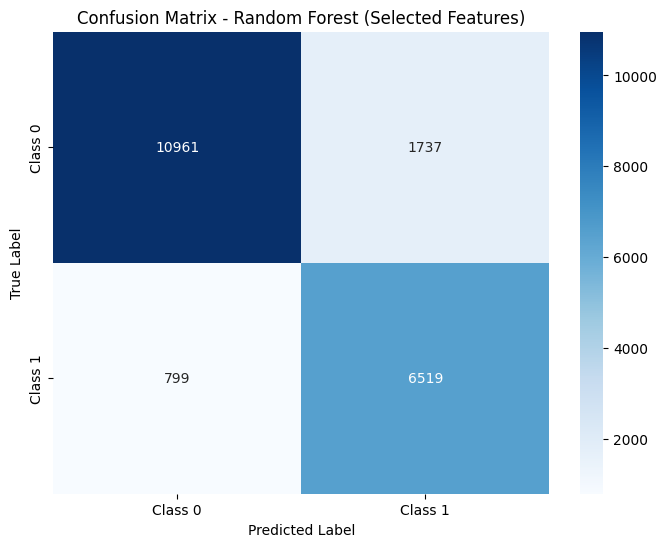

Shape of shap_values: (20016, 4, 2)
Shape of X_test_selected: (20016, 4)
Shape of shap_values after selection: (20016, 4, 2)


<Figure size 640x480 with 0 Axes>

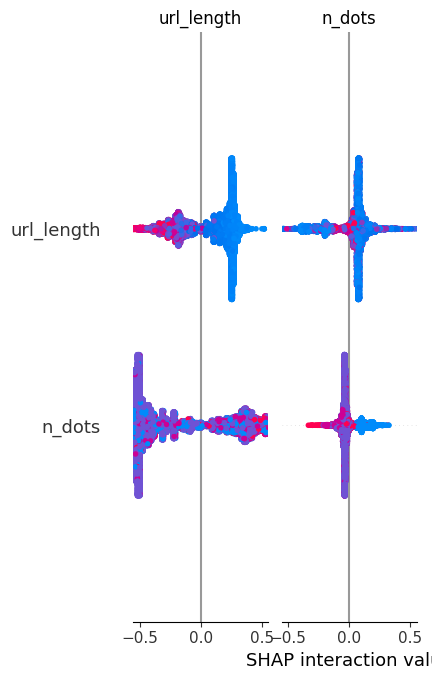

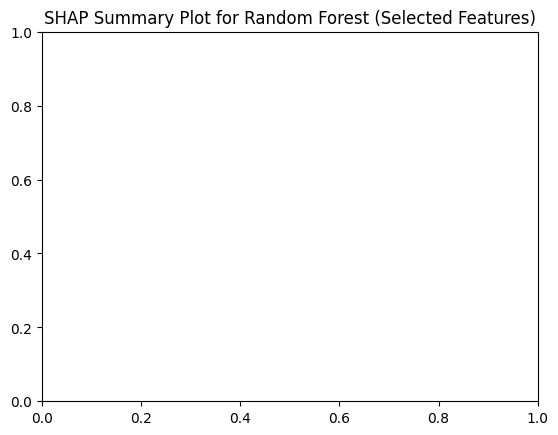

<Figure size 640x480 with 0 Axes>

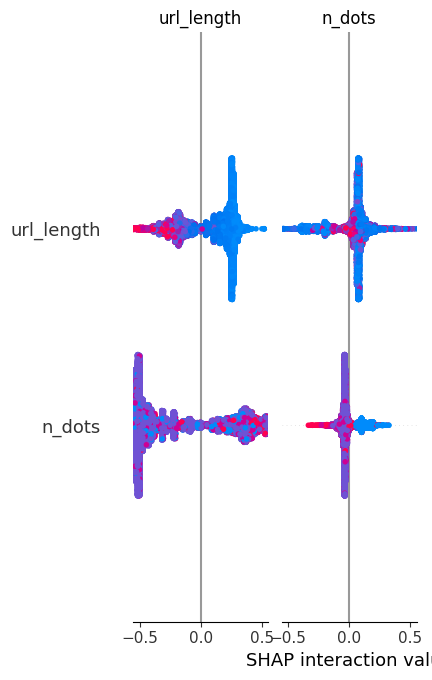

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

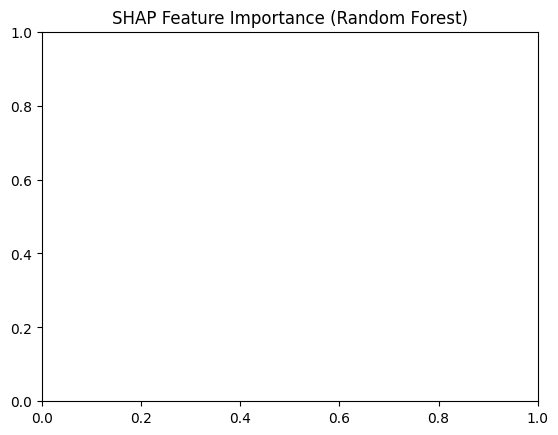

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os  

# Set the logical cores count for parallelism (if needed)
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

# Track start time
start_time = time.time()

# Step 1: Load dataset
df = pd.read_csv('ds_100K20.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using Random Forest
# Train an initial Random Forest model to get feature importances
rf_initial_model = RandomForestClassifier(random_state=42)
rf_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on Random Forest feature importances
feature_selector = SelectFromModel(rf_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by Random Forest: {selected_features}")

# Step 6: Train final Random Forest model with selected features
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = rf_model.predict(X_test_selected)
y_proba = rf_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
rf_accuracy = accuracy_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")

print(f"Random Forest Accuracy (Selected Features): {rf_accuracy}")
print(f"Random Forest ROC-AUC (Selected Features): {rf_roc_auc}")
print("Random Forest Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - Random Forest (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for Random Forest
# Create a SHAP explainer for Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Check the shapes of shap_values and X_test_selected to ensure they match
print(f"Shape of shap_values: {np.array(shap_values).shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

# For binary classification, use shap_values[1] for class 1
if isinstance(shap_values, list) and len(shap_values) > 1:
    shap_values = shap_values[1]

# Check again after selecting the correct class shap_values
print(f"Shape of shap_values after selection: {shap_values.shape}")

# Ensure that SHAP values and X_test_selected have compatible shapes
assert shap_values.shape[1] == X_test_selected.shape[1], "Shape mismatch between SHAP values and test set!"

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for Random Forest (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (Random Forest)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 1
#plt.figure()
#shap.force_plot(explainer.expected_value[1], shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
#plt.title(f"SHAP Force Plot for Sample {sample_index} (Random Forest)")
#plt.show()

shap.summary_plot(shap_values, X, plot_type="bar")

